# Week 5 Assignment
*Chapter 6 Excercises (Sec 6.11)*

## Story 1 - One-sample Two-sided t-test: Average Hours on Homework
A school principal believes that the average number of hours students spend on homework each week
is not equal to 10 hours. To test this claim, a sample of weekly homework hours from selected students is
collected. The data on the number of hours spent on homework is as follows:

In [26]:
homework_hours = [9, 12, 10, 11, 8, 14, 9, 11, 12, 13, 8, 10, 9, 11, 10, 12, 9, 10, 8, 11]

#### Develop the hypothesis statements, interpret the results, and explain its Type I error and Type II error.

In [31]:
import numpy as np
from scipy import stats

mu_0 = 10

t_statistic, p_value = stats.ttest_1samp(homework_hours, mu_0)

print(f"Sample Mean: {np.mean(homework_hours):.3f}")
print(f"T-Statistic: {t_statistic:.3f}")
print(f"P-Value: {p_value:.4f}")

Sample Mean: 10.350
T-Statistic: 0.924
P-Value: 0.3672


#### Conclusion

There is no evidence that the true average homework time differs from 10 hours. A type I error has occured, meaning the principal's conclusion that the average homework time is not 10 hours when it actually is 10 hours. A type II error would occur when the principal concludes the average homework time is 10 hours when it actually is not 10 hours.

## Story 2 - One-sample One-sided t-test: Average Product Weight
A manufacturer claims that the average weight of their product is greater than 500 grams. To test this
claim, a sample of product weights is collected. The data on the weights (in grams) of the sample are as
follows:

In [32]:
weights = [505, 510, 490, 520, 515, 530, 495, 510, 500, 505, 525, 515, 490, 520, 505]

#### Develop the hypothesis statements, interpret the results, and explain its Type I error and Type II error

In [33]:
import numpy as np
from scipy import stats

mu_0 = 500

t_statistic, p_two_sided = stats.ttest_1samp(weights, mu_0)

if t_statistic > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - (p_two_sided / 2)

print(f"Sample Mean: {np.mean(weights):.3f}")
print(f"T-Statistic: {t_statistic:.3f}")
print(f"One-Sided P-Value: {p_one_sided:.4f}")

Sample Mean: 509.000
T-Statistic: 2.874
One-Sided P-Value: 0.0061


#### Conclusion
There is strong statistical evidence that the manufacturers claim that the true average product weight is greater than 500 grams is correct.
A type 1 error would occur if we assume the average product weight is greater than 500 g, when in reality it is not greater than 500 g.
A type 2 error would occur if we assume the average weight is not greater than 500 g, when in reality it is greater than 500 g


## Story 3: Adjusting the Sample Size
A researcher is testing the effectiveness of a new weight-loss program. The null hypothesis (H0) is
that the program has no effect on weight loss, and the alternative hypothesis (H1) is that the program
leads to weight loss. Initially, the study includes only 10 participants, and the results fail to reject the null
hypothesis.
1. Explain how increasing the sample size could affect the probability of making a Type II error in this
study.
2. Would increasing the sample size affect the probability of making a Type I error? Why or why not?
3. If the true effect of the program is small, why might a larger sample size be particularly important
for detecting it?

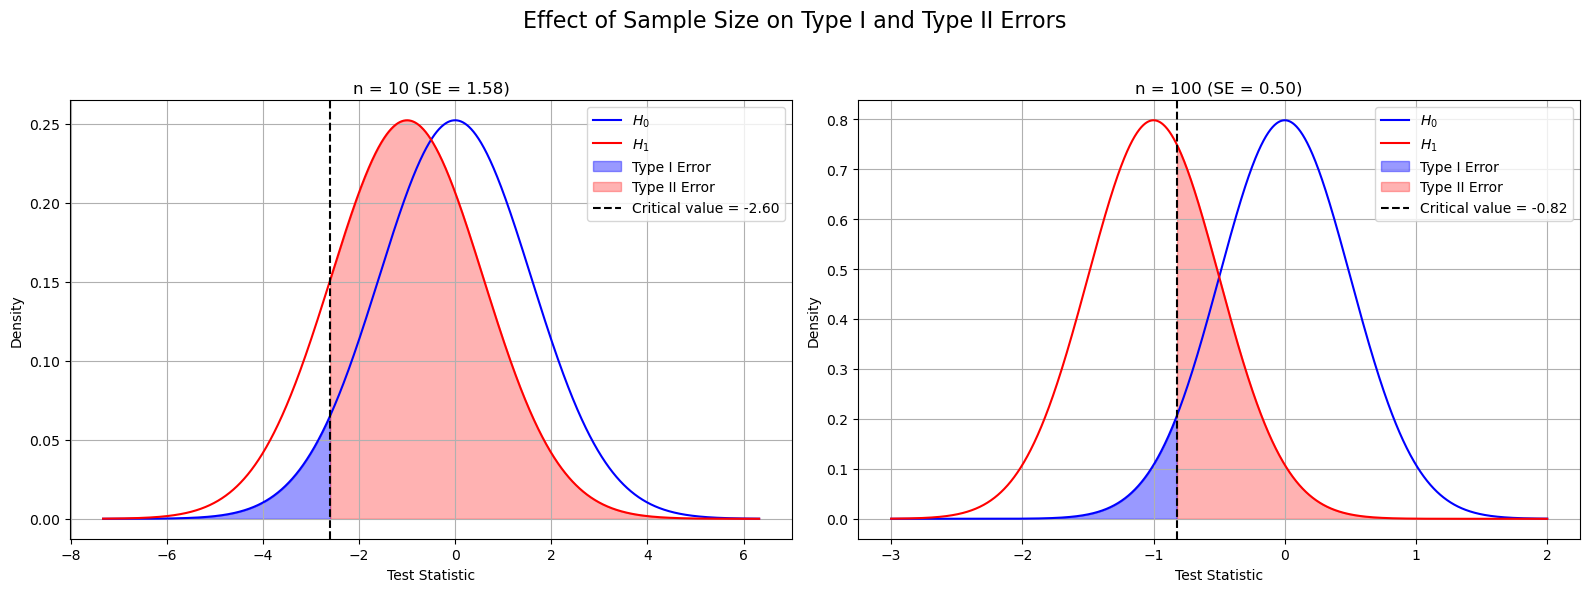

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

mu_null = 0
sigma = 5
alpha = 0.05

mu_alt = -1 # Assumed

sample_sizes = [10, 100]

plt.figure(figsize=(16, 6))

for i, n in enumerate(sample_sizes, 1):
    se = sigma / np.sqrt(n)
    x = np.linspace(mu_alt - 4*se, mu_null + 4*se, 2000)
    y_null = stats.norm.pdf(x, mu_null, se)
    y_alt = stats.norm.pdf(x, mu_alt, se)
    critical_value = stats.norm.ppf(alpha, loc=mu_null, scale=se)
    
    plt.subplot(1, 2, i)
    plt.plot(x, y_null, label=r'$H_0$', color='blue')
    plt.plot(x, y_alt, label=r'$H_1$', color='red')
    
    plt.fill_between(x, 0, y_null, where=(x < critical_value),
                     color='blue', alpha=0.4, label='Type I Error')
    
    plt.fill_between(x, 0, y_alt, where=(x >= critical_value),
                     color='red', alpha=0.3, label='Type II Error')
    
    plt.axvline(critical_value, color='black', linestyle='--',
                label=f'Critical value = {critical_value:.2f}')
    
    plt.title(f'n = {n} (SE = {se:.2f})')
    plt.xlabel('Test Statistic')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)

plt.suptitle('Effect of Sample Size on Type I and Type II Errors', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Conclusion
1) As we expect, when the sample size increases the standard error decreases, reducing the probability of a Type II error.
2) Type I error is not effected as it is set in the test itself. ($\alpha = 0.05$ in this case.)
3) With a larger sample, the standard error shrinks, so even a small true difference can produce a statistically significant t‑statistic

## Story 4: Understanding the t-Distribution
A researcher is comparing the average test scores of a small group of students ($n = 6$) to a national average. They choose to use a t-statistic instead of a z-score for their hypothesis test.

#### 1. Why is the t-distribution more appropriate than the standard normal distribution (z-score) in this case?
Because the sample is small ($n = 6$) and the population standard deviation is unknown. The t‑distribution is designed for situations where the sample standard deviation $s$ replaces the unknown population standard deviation $\sigma$ , so it correctly reflects the uncertainty in the estimate of variability. 

#### 2. How does the t-distribution adjust for the uncertainty associated with small sample sizes?
The distribution depends on $df=n-1$; smaller $df$ (smaller $n$) produces wider, heavier‑tailed curves that reflect greater uncertainty.

#### 3. As the sample size increases, what happens to the shape of the t-distribution compared to the standard normal distribution?
As the sample size increases, the t‑distribution approaches the standard normal distribution.